In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [2]:
df=pd.read_csv("migraine_prediction_dataset.csv")

In [3]:
df.head()

,Age,Gender,Migraine_Frequency,Warning_Signs_Before,Sleep_Trigger,Duration_of_Migraine,Takes_Medicine,Feels_Dizzy_Before,Caffeine_Helps,Water_Helps
0,57,1,2,1,0,1,0,1,0,0
1,25,0,1,2,1,1,0,0,1,0
2,46,0,3,1,1,1,1,0,0,0
3,37,1,1,1,1,0,1,1,1,1
4,45,0,1,2,1,2,0,0,1,0


In [4]:
def f(row):
   
    if row['Migraine_Frequency'] == 3.0 or row['Migraine_Frequency'] == 2.0:
        val = 'moderate migraine'

    elif row['Migraine_Frequency'] == 1.0:
        val = 'low migraine'

    elif row['Migraine_Frequency'] == 4.0:
        val = 'high migraine'

    else:
        val = 'no_migraine'
    return val

df['Migraine_Frequency'] = df.apply(f, axis=1)
df.head()

,Age,Gender,Migraine_Frequency,Warning_Signs_Before,Sleep_Trigger,Duration_of_Migraine,Takes_Medicine,Feels_Dizzy_Before,Caffeine_Helps,Water_Helps
0,57,1,moderate migraine,1,0,1,0,1,0,0
1,25,0,low migraine,2,1,1,0,0,1,0
2,46,0,moderate migraine,1,1,1,1,0,0,0
3,37,1,low migraine,1,1,0,1,1,1,1
4,45,0,low migraine,2,1,2,0,0,1,0


In [8]:
df.drop('Duration_of_Migraine',axis=1,inplace=True)
df.drop('Warning_Signs_Before',axis=1,inplace=True)

In [ ]:
features=['Age','Gender','Sleep_Trigger','Takes_Medicine','Feels_Dizzy_Before','Caffeine_Helps','Water_Helps']
x=df[features]
y=df[['Migraine_Frequency']]


x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


     Age  Gender  Sleep_Trigger  Takes_Medicine  Feels_Dizzy_Before  \
0     57       1              0               0                   1   
1     25       0              1               0                   0   
2     46       0              1               1                   0   
3     37       1              1               1                   1   
4     45       0              1               0                   0   
..   ...     ...            ...             ...                 ...   
995   38       1              1               1                   1   
996   33       0              1               0                   0   
997   40       1              0               1                   1   
998   44       1              1               1                   1   
999   15       0              1               1                   1   

     Caffeine_Helps  Water_Helps  
0                 0            0  
1                 1            0  
2                 0            0  
3      

In [11]:
model=LogisticRegression(solver='liblinear',max_iter=1000)
model.fit(x_train,y_train)
print("Model training complete")

Model training complete


d:\TechAxis\venv\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [12]:
y_pred=model.predict(x_test)

In [13]:
#Accuracy
acc=accuracy_score(y_test,y_pred)
print(f"\nAccuracy: {acc:.2f}")

#Detailed classification report 
print("\nClassification Report: ")
print(classification_report(y_test,y_pred))


Accuracy: 0.33

Classification Report: 
                   precision    recall  f1-score   support

    high migraine       0.00      0.00      0.00        47
     low migraine       0.17      0.03      0.04        39
moderate migraine       0.33      0.96      0.49        67
      no_migraine       0.00      0.00      0.00        47

         accuracy                           0.33       200
        macro avg       0.12      0.25      0.13       200
     weighted avg       0.14      0.33      0.17       200



d:\TechAxis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\TechAxis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\TechAxis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
Outcome=model.predict([[30,1,0,1,0,1,1]])
print(Outcome)

['moderate migraine']


d:\TechAxis\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [15]:
from sklearn.neighbors import KNeighborsClassifier
y_t=list(y_test)
error_rates=[]
for i in range(1,41):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    pred=knn.predict(x_test)

    sum=0
    score=[]
    for j in range(0,len(y_t)):
        if pred[j]==y_t[j]:
            score.append(0)

        else:
            score.append(1)
    
    for m in score:
        if m==1:
            sum=sum+m
    
    error_rates.append(sum/len(score))

d:\TechAxis\venv\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
d:\TechAxis\venv\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
d:\TechAxis\venv\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
d:\TechAxis\venv\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel(

Minimum error: 1.0 at k= 40


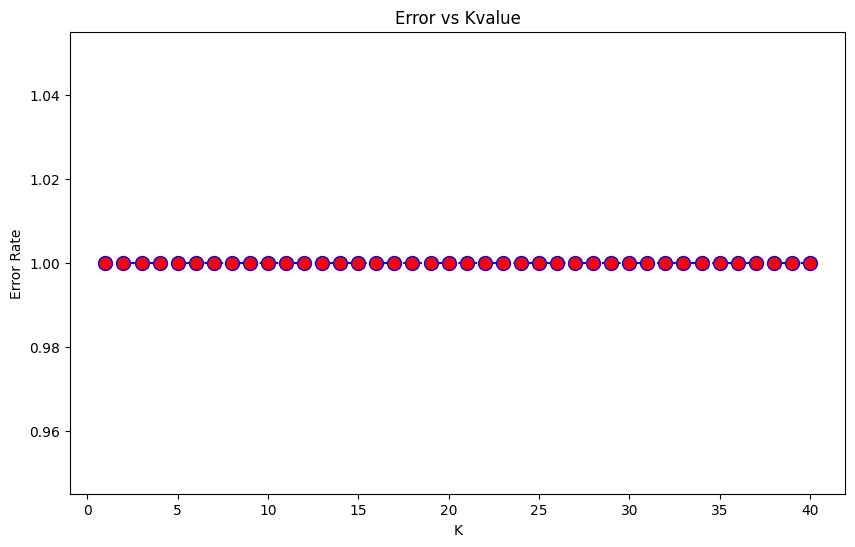

In [16]:
plt.figure(figsize=(10,6))
plt.plot(range(1,41),error_rates,color='blue',linestyle='dashed',marker='o',markerfacecolor='red',markersize=10)
plt.title("Error vs Kvalue")
plt.xlabel('K')
plt.ylabel('Error Rate')
rev_error_rates=error_rates[::-1]
req_k_value=len(rev_error_rates)-rev_error_rates.index(min(error_rates))
print("Minimum error:",min(error_rates),"at k=",req_k_value)
